# Notebook: Validation Generated QAs From E.R.Stitt Book

This notebook serves to validate a generated Question-Answering (QA) dataset This dataset is intended for testing and subsequent evaluation of a Tropical Disease Diagnosis System. The source material for this QA dataset is 'The diagnostics and treatment of tropical diseases' by E. R. Stitt.

## 1. Set up

In [ ]:
!pip install google-generativeai tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import google.generativeai as genai

genai.configure(api_key="Gemini API Key")                                                     ## Insert Gemini API here
model = genai.GenerativeModel("gemini-2.5-flash")

try:
    response = model.generate_content("Hello Gemini!")
    print("API key works normally!")
    print(response.text)
except Exception as e:
    print("ERROR: Wrong API key", e)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


API key works normally!
Hello! It's great to connect with you. I'm Gemini, and I'm here and ready to help.

What's on your mind? How can I assist you today?


In [ ]:
import os
# PATHS CONFIGURATION
RAW_QAs = "/content/drive/MyDrive/Clinical LMM Project/Data Validation/E.R.Stitt_Book_Dataset-validation/testQA(official)_multi.json"         # Path to raw QAs dataset need to be validated
SOURCE_JSON_DIR = "/content/drive/MyDrive/Clinical LMM Project/Texts & Images Extraction/E.R.Stitt_Book_Data Preparation/Chapter_Extraction"  # Path to source files of Book Extracted JSON (generating the raw QAs dataset)
OUTPUT_DIR = "/content/drive/MyDrive/Clinical LMM Project/Data Validation/E.R.Stitt_Book_Dataset-validation/Report"                           # Path to output folder, where will save the validation report
os.makedirs(OUTPUT_DIR, exist_ok=True)



In [ ]:
def load_source_json(filename):
    """Loads the specific chapter JSON required for validation."""
    path = os.path.join(SOURCE_JSON_DIR, filename)
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.dumps(json.load(f))
    except Exception as e:
        return None

## 2. THE FIDELITY CHECK

This prompt acts as a Senior Medical Editor validator designed to ensure data integrity before training. Its primary goal is to catch "hallucinations" and "data leakage" without being overly pedantic about wording.

The 3 Red Lines it polices:

1. Factual Contradictions: Does the case say "Treatable" when the text says "Fatal"?

2. Answer Leakage: Does the question accidentally reveal the diagnosis (e.g., "A patient with Malaria...")?

3. Logical Consistency: Are the symptoms and diagnosis mutually compatible?

Output Mechanism: returns a structured JSON verdict (flags and comments), acting as an automated "Go/No-Go" gauge.

In [ ]:
FIDELITY_PROMPT = """
You are a senior medical editor reviewing a diagnostic teaching case derived from
a historical medical source.

Your task is to decide whether the case is ACCEPTABLE for educational use.
This is a permissive, teaching-oriented fidelity review.

Your role is evaluative only.
Do NOT rewrite, correct, or improve the case.
ONLY flag clear violations.

=====================
INPUTS
=====================

1. SOURCE REPORT (Historical Ground Truth):
{source_json_content}

2. TEACHING CASE DRAFT:
- Vignette: "{question}"
- Final Diagnosis: "{answer}"
- Diagnostic Rationale: "{rationale}"

=====================
REVIEW PHILOSOPHY
=====================

Prioritize educational plausibility over strict textual matching.

The following are ACCEPTABLE and must NOT be flagged:
- Reasonable clinical inference not explicitly stated in the source
- Typical laboratory or imaging patterns mentioned illustratively
- General epidemiology or pathophysiology statements
- Implicit negatives if not contradicted
- Minor descriptive variation that does not alter diagnostic meaning
- Teaching-oriented explanations using general medical knowledge

=====================
FLAG ONLY IF
=====================

A case MUST be flagged only if it contains one or more of the following:

1. Direct contradiction of the source report
2. Biologically or epidemiologically impossible findings
3. Fabricated patient-specific facts that materially alter the diagnosis
4. Internal inconsistency (e.g., conflicting diagnoses)
5. Final diagnosis explicitly revealed in the vignette
6. Mutually exclusive or incompatible hallmark features combined


=====================
OUTPUT FORMAT (JSON ONLY)
=====================

Return ONLY a valid JSON object.

"flags":
- Use one or more of:
  - CASE_PROMPT_HALLUCINATION
  - DIAGNOSTIC_REASONING_HALLUCINATION
  - FINAL_DIAGNOSIS_IN_CASE_PROMPT
  - OTHER
- If no violations remain after the Global Knowledge Sanity Check:
  ["NONE"]

"editorcomments":
- One concise sentence per retained flag
- Omit or leave empty if flags = ["NONE"]
"""

In [ ]:
import os
import json
from tqdm import tqdm
def run_fidelity_check(qa_item):
    """
    Executes Judge 1 (Fidelity/Forensic Audit).
    Returns a dict with 'status': 'PASSED_FIDELITY' or 'REJECTED'.
    """

    # 1. Load Ground Truth
    source_filename = qa_item.get("source_file")
    source_content = load_source_json(source_filename)

    if not source_content:
        return {"status": "ERROR", "reason": f"Source file {source_filename} not found"}

    # 2. Prepare the Prompt
    fidelity_input = FIDELITY_PROMPT.format(
        source_json_content=source_content,
        question=qa_item["question"],
        answer=qa_item["answer"],
        rationale=qa_item["clinical_rationale"]
    )

    # 3. Call the Model
    try:
        response_1 = model.generate_content(fidelity_input)
        text_resp = response_1.text.replace("```json", "").replace("```", "").strip()

        if "{" in text_resp:
             text_resp = text_resp[text_resp.find("{"):text_resp.rfind("}")+1]

        fidelity_result = json.loads(text_resp)
    except Exception as e:
        return {"status": "ERROR", "reason": f"Fidelity API/Parse Error: {e}"}

    # 4. Analyze Flags
    flags = fidelity_result.get("flags", [])
    has_issues = False

    if isinstance(flags, list):
        clean_flags = [f for f in flags if f != "NONE"]
        if len(clean_flags) > 0:
            has_issues = True
    elif isinstance(flags, str):
        if flags != "NONE":
            has_issues = True

    # 5. Return Verdict
    if has_issues:
        return {
            "status": "REJECTED",
            "reason": "Fidelity/Hallucination Issue",
            "flags": flags,
            "details": fidelity_result.get("editorcomments", {})
        }
    else:
        # SUCCESS CASE
        return {
            "status": "PASSED_FIDELITY",
            "reason": "No hallucinations found",
            "details": fidelity_result.get("editorcomments", {})
        }


In [ ]:
# ---------------------------------------------------------
# TEST BLOCK
# ---------------------------------------------------------
if __name__ == "__main__":
    test_item =   {
    "question": "A 35-year-old male, a European expatriate working for an international aid organization, presents with a two-week history of intermittent fevers, with temperatures typically normal in the morning but spiking to 102.5°F (39.2°C) in the evenings. He also reports experiencing severe headaches, insomnia, and a persistent rapid pulse of 105 beats per minute even at rest. On examination, he is found to have enlarged posterior cervical lymph nodes, described as discrete and non-tender. He notes developing some itchy papules on his trunk and some mild swelling around his eyes. He denies any recent travel outside of his assignment in Kwango Province, Democratic Republic of Congo. What is the diagnosis of this patient?",
    "answer": "West African Trypanosomiasis (Gambiense form) in the early stage",
    "disease_specific_focus": "African Trypanasomiasis",
    "clinical_rationale": "The patient's demographics, including being a European expatriate working in Kwango Province, Democratic Republic of Congo, place him in a region highly endemic for African Trypanosomiasis, a risk factor amplified by his occupational exposure in this area.\n\nThe presenting symptoms strongly suggest the initial stage of African Trypanosomiasis, often referred to as 'trypanosome fever.' The characteristic irregular fever with low morning temperatures and high evening rises (up to 103°F or higher) is present. The rapid, low-tension pulse rate (90-120 bpm) at all times is also a classic finding. Neurological symptoms such as headache and insomnia, along with difficulty concentrating, are early manifestations. The prominent glandular enlargement, specifically the posterior cervical lymph nodes (Winterbottom's sign), is a hallmark of the early stage. The description of itchy papules and localized oedematous swellings, particularly the erythematous rings seen in Europeans, further supports this diagnosis. The incubation period of about two to three weeks aligns with the patient's timeline.\n\nWhile some symptoms like fever and headache could overlap with other febrile illnesses such as malaria or dengue fever, the constellation of findings, particularly the characteristic fever pattern, rapid pulse, posterior cervical lymphadenopathy, and specific skin manifestations in an expatriate from an endemic region, makes African Trypanosomiasis the most probable diagnosis. Other differential diagnoses like syphilis can cause glandular enlargement, but the systemic febrile illness and other specific signs are not consistent. Malaria typically presents with more consistent fever patterns and splenomegaly is more common than posterior cervical lymphadenopathy.\n\nFinal Diagnosis: African Trypanosomiasis",
    "source_file": "CHAPTER_III_TheTrypanosomiases.json",
  }

    print(" ====== Fidelity Check Test ========")
    result = run_fidelity_check(test_item)
    print(json.dumps(result, indent=2))


 ====== Fidelity Check Test ========
{
  "status": "PASSED_FIDELITY",
  "reason": "No hallucinations found",
  "details": ""
}


## 3. Quality Check
This prompt acts as an Expert Medical Educator to assess the pedagogical value of the generated case. Unlike the Fidelity check (which checks if the facts are true), this check ensures the case is rich enough to teach a model how to think.

The 5-Point Evaluation Rubric:

- Thoroughness: Does the patient have a full history, vitals, and exam? (Fixes the "Ghost Patient" issue).

- Differential Diagnosis: Does the reasoning explicitly discuss and rule out alternative diseases? (Crucial for training reasoning models).

- Integrative Reasoning: Does the case require connecting multiple dots (synthesis), or is it just a simple keyword match?

- Transparency: Is the "why" clearly explained step-by-step?

- Stated Diagnosis: Is the final answer specific?

Output Mechanism: Calculates a numeric score (1-5) and a definitive status ("KEEP" or "DISCARD"), remains "high-signal" data (Average Score ≥ 3)

In [ ]:
QUALITY_PROMPT = """
You are an expert medical educator tasked with evaluating a generated "Teaching Case" (Question/Answer pair) for its diagnostic-reasoning value.
Your goal is to ensure the case has the style and rigor of a diagnostic teaching case from a medical textbook.

### INPUTS TO EVALUATE
1. **CASE PRESENTATION (The Vignette):** "{question}"

2. **DIAGNOSTIC REASONING (The Rationale):** "{rationale}"

3. **FINAL DIAGNOSIS (The Answer):** "{answer}"

### EVALUATION RUBRIC
Apply the following 5 criteria strictly.

**1. THOROUGHNESS OF CASE PRESENTATION (Score 1-5)**
*Look for: HPI, past history, meds, allergies, vitals, focused exam, labs, imaging, timeline.*
* **1 (Seriously deficient):** Identifiers only; no vitals.
* **2 (Major gaps):** HPI + vitals OR exam, but not both.
* **3 (Adequate):** Present but sketchy details.
* **4 (Very good):** Complete data, clear timeline.
* **5 (Exemplary):** Serial data & course, high quality, rich clinical texture.

**2. EXPLICIT DIFFERENTIAL DIAGNOSIS (Yes / No)**
*Does the Rationale discuss >=2 plausible alternatives?*
* **Yes:** Mentions and rules out at least one other plausible disease.
* **No:** Only discusses the correct diagnosis.

**3. DEPENDENCE ON INTEGRATIVE CLINICAL REASONING (Score 1-5)**
*Measures need to combine >=2 data points (hx, labs, demographics, etc) to reach the Answer.*
* **1 (Trivial):** Lone clue gives answer (e.g., "Patient has Koplik spots" -> Measles).
* **2 (Minimal):** One dominant clue.
* **3 (Moderate):** Must merge TWO findings.
* **4 (High):** THREE+ clues; requires synthesis.
* **5 (Outstanding):** Stepwise, complex reasoning required.

**4. TRANSPARENCY OF DIAGNOSTIC REASONING PROCESS (Score 1-5)**
*Evaluate the 'Clinical Rationale' field.*
* **1 (None):** No rationale provided.
* **2 (Superficial):** Lists facts without the "why" or logic.
* **3 (Adequate):** Brief pivots or logical steps.
* **4 (Detailed):** Stepwise deduction, probabilistic thinking.
* **5 (Model):** Structured, addresses pitfalls, highly educational.

**5. STATED FINAL DIAGNOSIS (Yes / No)**
*Is the diagnosis clearly named in the 'Answer' field?*
* **Yes:** Specific disease named (e.g., "Vivax Malaria").
* **No:** Vague or missing (e.g., "A parasitic infection").

### OUTPUT FORMAT (JSON ONLY)
{{
  "scores": {{
    "thoroughness": (1-5),
    "explicit_differential": "Yes" or "No",
    "integrative_reasoning": (1-5),
    "transparency": (1-5),
    "stated_diagnosis": "Yes" or "No"
  }},
  "average_numeric_score": (Calculate the average of the three 1-5 scores),
  "critique": "Brief explanation of the reasoning behind these scores.",
  "status": "KEEP" (if Average Score >= 3 and Stated Diagnosis is Yes) or "DISCARD"
}}
"""

In [ ]:
import json

def run_quality_check(qa_item):
    """
    Runs the Quality Validation (Judge 2).
    Evaluates the pedagogical value of the QA pair.
    """

    # 1. Prepare Input
    quality_input = QUALITY_PROMPT.format(
        question=qa_item["question"],
        answer=qa_item["answer"],
        rationale=qa_item["clinical_rationale"]
    )

    # 2. Call the Model
    try:
        response = model.generate_content(quality_input)
        text_resp = response.text.replace("```json", "").replace("```", "").strip()

        if "{" in text_resp:
             text_resp = text_resp[text_resp.find("{"):text_resp.rfind("}")+1]

        quality_result = json.loads(text_resp)
    except Exception as e:
        return {"status": "ERROR", "reason": f"Quality API/Parse Error: {e}"}

    # 3. Determine Verdict based on LLM's "status" field
    final_status = quality_result.get("status", "DISCARD")

    if final_status == "KEEP":
        return {
            "status": "APPROVED",
            "scores": quality_result.get("scores", {}),
            "average_score": quality_result.get("average_numeric_score"),
            "critique": quality_result.get("critique")
        }
    else:
        return {
            "status": "REJECTED",
            "reason": f"Low Quality Score (Avg: {quality_result.get('average_numeric_score')})",
            "critique": quality_result.get("critique"),
            "scores": quality_result.get("scores", {})
        }



In [ ]:
# ---------------------------------------------------------
# TEST BLOCK
# ---------------------------------------------------------
if __name__ == "__main__":
    test_item = {
        "question": "A 35-year-old male, a European expatriate working for an international aid organization, presents with a two-week history of intermittent fevers, with temperatures typically normal in the morning but spiking to 102.5°F (39.2°C) in the evenings. He also reports experiencing severe headaches, insomnia, and a persistent rapid pulse of 105 beats per minute even at rest. On examination, he is found to have enlarged posterior cervical lymph nodes, described as discrete and non-tender. He notes developing some itchy papules on his trunk and some mild swelling around his eyes. He denies any recent travel outside of his assignment in Kwango Province, Democratic Republic of Congo. What is the diagnosis of this patient?",
        "answer": "West African Trypanosomiasis (Gambiense form) in the early stage",
        "clinical_rationale": "The patient's demographics, including being a European expatriate working in Kwango Province, Democratic Republic of Congo, place him in a region highly endemic for African Trypanosomiasis, a risk factor amplified by his occupational exposure in this area. The presenting symptoms strongly suggest the initial stage of African Trypanosomiasis, often referred to as 'trypanosome fever.' The characteristic irregular fever with low morning temperatures and high evening rises (up to 103°F or higher) is present. The rapid, low-tension pulse rate (90-120 bpm) at all times is also a classic finding. Neurological symptoms such as headache and insomnia, along with difficulty concentrating, are early manifestations. The prominent glandular enlargement, specifically the posterior cervical lymph nodes (Winterbottom's sign), is a hallmark of the early stage. The description of itchy papules and localized oedematous swellings, particularly the erythematous rings seen in Europeans, further supports this diagnosis. The incubation period of about two to three weeks aligns with the patient's timeline. While some symptoms like fever and headache could overlap with other febrile illnesses such as malaria or dengue fever, the constellation of findings, particularly the characteristic fever pattern, rapid pulse, posterior cervical lymphadenopathy, and specific skin manifestations in an expatriate from an endemic region, makes African Trypanosomiasis the most probable diagnosis. Other differential diagnoses like syphilis can cause glandular enlargement, but the systemic febrile illness and other specific signs are not consistent. Malaria typically presents with more consistent fever patterns and splenomegaly is more common than posterior cervical lymphadenopathy. Final Diagnosis: African Trypanosomiasis",
        "source_file": "CHAPTER_III_TheTrypanosomiases.json"
    }

    print("============ Quality Check (Judge 2) Test ============")
    result = run_quality_check(test_item)
    print(json.dumps(result, indent=2))

============ Quality Check (Judge 2) Test ============
{
  "status": "APPROVED",
  "scores": {
    "thoroughness": 3,
    "explicit_differential": "Yes",
    "integrative_reasoning": 4,
    "transparency": 4,
    "stated_diagnosis": "Yes"
  },
  "average_score": 3.67,
  "critique": "The case presentation provides a good HPI, some vitals, and a focused exam, but lacks crucial details such as full vital signs, comprehensive past medical history, medications, allergies, and any laboratory or imaging results, which are standard in a thorough teaching case. The diagnostic reasoning, however, is excellent. It demonstrates high integrative reasoning by requiring the synthesis of multiple epidemiological and clinical clues (geographic location, occupation, fever pattern, specific lymphadenopathy, skin lesions, neurological symptoms). The transparency of the reasoning is detailed and clear, explicitly linking each piece of evidence to the diagnosis and effectively ruling out plausible different

## 4. Final Loop

In [ ]:
import os
import json
import time
from tqdm import tqdm

# ==============================================================================
# LOAD DATA
# ==============================================================================
if not os.path.exists(RAW_QAs):
    raise FileNotFoundError(f" Raw QA file not found at {RAW_QAs}")

with open(RAW_QAs, 'r', encoding='utf-8') as f:
    generated_qas = json.load(f)

passed_dataset = []
reviewed_dataset = []
full_report_log = []

print(f"Starting Dual-Validation Pipeline for {len(generated_qas)} items...")

# ==============================================================================
# MAIN LOOP
# ==============================================================================
for qa in tqdm(generated_qas, desc="Validating"):

    question_text = qa.get("question", "")

    qa_report_entry = {
        "source_file": qa.get("source_file"),
        "question_snippet": question_text[:100] + "...",
        "fidelity_check": {},
        "quality_check": {},
        "final_decision": "PENDING"
    }

    # --- Run checks ---
    fidelity_result = run_fidelity_check(qa)
    quality_result = run_quality_check(qa)

    qa_report_entry["fidelity_check"] = fidelity_result
    qa_report_entry["quality_check"] = quality_result

    if (
        fidelity_result.get("status") == "PASSED_FIDELITY"
        and quality_result.get("status") == "APPROVED"
    ):
        qa_report_entry["final_decision"] = "VALID_QA"
        passed_dataset.append(qa)
    else:
        qa_report_entry["final_decision"] = "NEEDS_REVIEW"
        reviewed_dataset.append(qa)

    full_report_log.append(qa_report_entry)

    time.sleep(1.5)

# ==============================================================================
# SAVE OUTPUTS
# ==============================================================================
valid_path = os.path.join(OUTPUT_DIR, "Passed_Dataset.json")
reviewed_path = os.path.join(OUTPUT_DIR, "Reviewed_Dataset.json")
report_path = os.path.join(OUTPUT_DIR, "Validation_Report.json")

with open(valid_path, 'w', encoding='utf-8') as f:
    json.dump(passed_dataset, f, indent=2)

with open(reviewed_path, 'w', encoding='utf-8') as f:
    json.dump(reviewed_dataset, f, indent=2)

with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(full_report_log, f, indent=2)

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "=" * 50)
print("PIPELINE COMPLETE")
print(f"Total Input:             {len(generated_qas)}")
print(f"Valid QAs Saved:         {len(passed_dataset)}")
print(f"Need Review QAs:         {len(reviewed_dataset)}")
print("-" * 50)
print(f"Valid Data:  {valid_path}")
print(f"Full Report: {report_path}")
print("=" * 50)


Starting Dual-Validation Pipeline for 30 items...


Validating: 100%|██████████| 30/30 [12:17<00:00, 24.57s/it]


PIPELINE COMPLETE
Total Input:             30
Valid QAs Saved:         24
Need Review QAs:         6
--------------------------------------------------
Valid Data:  /content/drive/MyDrive/Clinical LMM Project/Data Validation/E.R.Stitt_Book_Dataset-validation/Report/Passed_Dataset.json
Full Report: /content/drive/MyDrive/Clinical LMM Project/Data Validation/E.R.Stitt_Book_Dataset-validation/Report/Validation_Report.json


### Overall Result

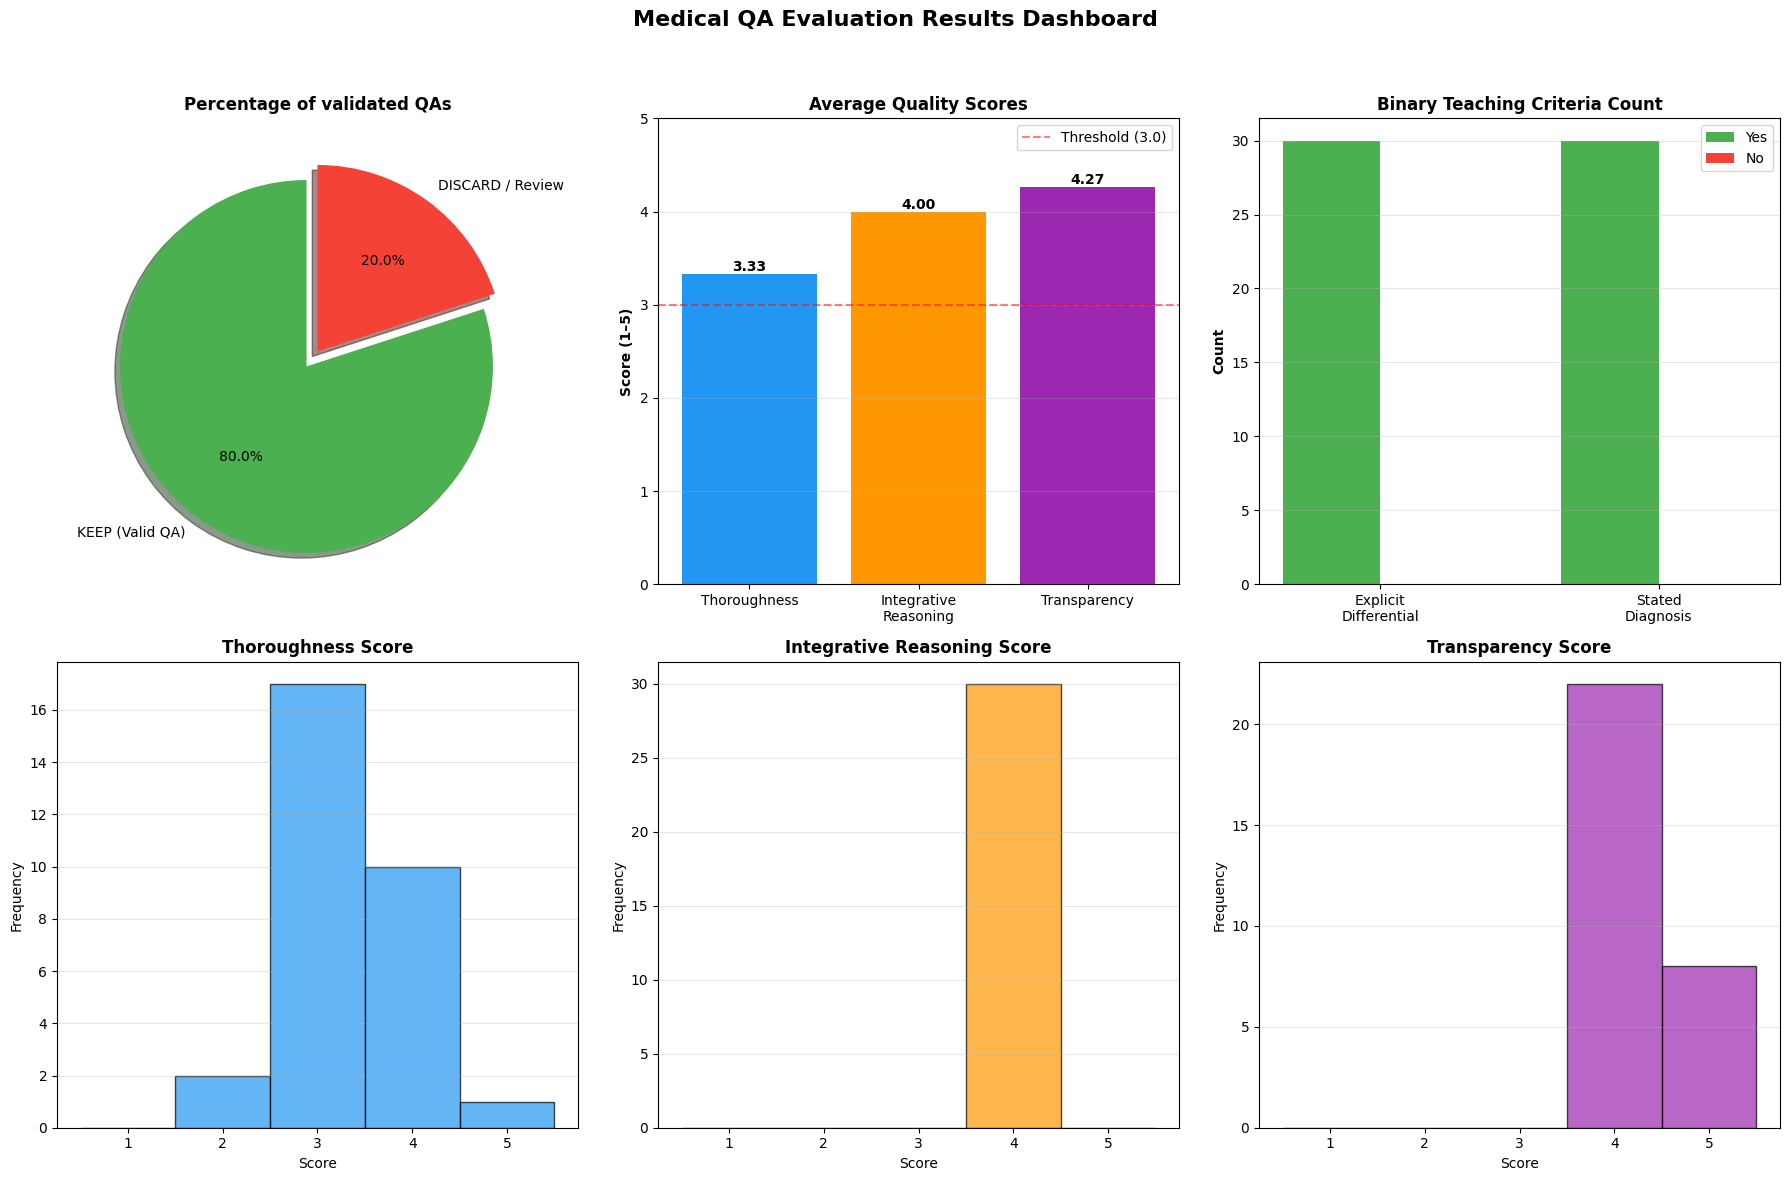

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load evaluation results

with open(report_path, 'r', encoding='utf-8') as f:
    evaluation_results = json.load(f)

# Preprocess data

final_decisions = [e.get("final_decision", "UNKNOWN") for e in evaluation_results]
keep_count = final_decisions.count("VALID_QA")
discard_count = len(final_decisions) - keep_count

quality_metrics = [
    e.get("quality_check", {})
    for e in evaluation_results
    if e.get("quality_check", {}).get("scores") is not None
]

# Average numeric scores
def safe_mean(values):
    vals = [v for v in values if isinstance(v, (int, float))]
    return sum(vals) / len(vals) if vals else 0

avg_thoroughness = safe_mean(
    [m["scores"].get("thoroughness") for m in quality_metrics]
)

avg_integrative = safe_mean(
    [m["scores"].get("integrative_reasoning") for m in quality_metrics]
)

avg_transparency = safe_mean(
    [m["scores"].get("transparency") for m in quality_metrics]
)

# Binary criteria counts
differential_yes = sum(
    1 for m in quality_metrics
    if m["scores"].get("explicit_differential") == "Yes"
)

diagnosis_stated_yes = sum(
    1 for m in quality_metrics
    if m["scores"].get("stated_diagnosis") == "Yes"
)

# =========================
# Visualization
# =========================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Medical QA Evaluation Results Dashboard', fontsize=16, fontweight='bold')

# 1. KEEP vs DISCARD Pie Chart
ax1 = axes[0, 0]
labels = ['KEEP (Valid QA)', 'DISCARD / Review']
sizes = [keep_count, discard_count]
colors = ['#4CAF50', '#F44336']
explode = (0.1, 0)

ax1.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)
ax1.set_title('Percentage of validated QAs', fontweight='bold')

# 2. Average Scores Bar Chart
ax2 = axes[0, 1]
metrics = ['Thoroughness', 'Integrative\nReasoning', 'Transparency']
scores = [avg_thoroughness, avg_integrative, avg_transparency]

bars = ax2.bar(metrics, scores, color=['#2196F3', '#FF9800', '#9C27B0'])
ax2.set_ylim(0, 5)
ax2.set_ylabel('Score (1–5)', fontweight='bold')
ax2.set_title('Average Quality Scores', fontweight='bold')
ax2.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Threshold (3.0)')

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Binary Criteria (Yes/No)
ax3 = axes[0, 2]
criteria = ['Explicit\nDifferential', 'Stated\nDiagnosis']
yes_counts = [differential_yes, diagnosis_stated_yes]
no_counts = [
    len(quality_metrics) - differential_yes,
    len(quality_metrics) - diagnosis_stated_yes
]

x = np.arange(len(criteria))
width = 0.35

ax3.bar(x - width / 2, yes_counts, width, label='Yes', color='#4CAF50')
ax3.bar(x + width / 2, no_counts, width, label='No', color='#F44336')

ax3.set_ylabel('Count', fontweight='bold')
ax3.set_title('Binary Teaching Criteria Count', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(criteria)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Thoroughness Histogram
ax4 = axes[1, 0]
thoroughness_scores = [
    m["scores"].get("thoroughness", 0) for m in quality_metrics
]

ax4.hist(
    thoroughness_scores,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    color='#2196F3',
    edgecolor='black',
    alpha=0.7
)

ax4.set_title('Thoroughness Score', fontweight='bold')
ax4.set_xlabel('Score')
ax4.set_ylabel('Frequency')
ax4.set_xticks([1, 2, 3, 4, 5])
ax4.grid(axis='y', alpha=0.3)

# 5. Integrative Reasoning Histogram
ax5 = axes[1, 1]
integrative_scores = [
    m["scores"].get("integrative_reasoning", 0) for m in quality_metrics
]

ax5.hist(
    integrative_scores,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    color='#FF9800',
    edgecolor='black',
    alpha=0.7
)

ax5.set_title('Integrative Reasoning Score', fontweight='bold')
ax5.set_xlabel('Score')
ax5.set_ylabel('Frequency')
ax5.set_xticks([1, 2, 3, 4, 5])
ax5.grid(axis='y', alpha=0.3)

# 6. Transparency Histogram
ax6 = axes[1, 2]
transparency_scores = [
    m["scores"].get("transparency", 0) for m in quality_metrics
]

ax6.hist(
    transparency_scores,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    color='#9C27B0',
    edgecolor='black',
    alpha=0.7
)

ax6.set_title('Transparency Score', fontweight='bold')
ax6.set_xlabel('Score')
ax6.set_ylabel('Frequency')
ax6.set_xticks([1, 2, 3, 4, 5])
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
